In [1]:
import xarray as xr
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import cartopy.feature as cfeature
import cartopy.mpl.ticker as cticker
import matplotlib.dates as mdates
import numpy as np

import intake

import sys
sys.path.append("/work/mh1498/m301248/TCO_data/COARE-algorithm/Python/COARE3.5/") 

sys.path.append("/work/mh1498/m301248/TCO_data/BCO_observational/mass_fluxes_profiles/yk22_mass_fluxes.py")
import yk22_mass_fluxes

import metpy

import meteo


import pandas as pd
from IPython.display import display, HTML

In [2]:
## constants I always need
Lv = 2.5e6  # J/kg
cp = 1004.7 # J/kg K

Rd = 287.   # J / kg K

In [9]:
beach  = xr.open_dataset("ipfs://bafybeibgeeqs5uhmbqy4hz4v3pihrfisiklcetisxkf63d2r473szaprwi", engine="zarr")  # level 4
beach3 = xr.open_dataset("ipfs://bafybeiczbv7mycr2jois6t4dq3zwiltycomwo5xxvjqcjz2ot3newzar6q", engine="zarr")  # level 3

In [43]:
beach

<xarray.Dataset> Size: 116MB
Dimensions:                   (circle: 89, altitude: 1460, sonde: 1058)
Coordinates:
    circle_lat                (circle) float32 356B 5.0 8.25 ... 12.17 10.76
    circle_lon                (circle) float32 356B -27.0 -26.39 ... -56.91
    circle_time               (circle) datetime64[ns] 712B ...
    sondes_per_circle         (circle) int64 712B 12 12 10 12 12 ... 14 14 12 13
  * altitude                  (altitude) float64 12kB 0.0 10.0 ... 1.459e+04
    launch_time               (sonde) datetime64[ns] 8kB ...
Dimensions without coordinates: circle, sonde
Data variables: (12/73)
    circle_altitude           (circle) float32 356B ...
    circle_id                 (circle) <U19 7kB ...
    circle_radius             (circle) float32 356B ...
    div                       (circle, altitude) float32 520kB ...
    div_sonde_relevance       (sonde, altitude) float32 6MB ...
    div_std_error             (circle, altitude) float32 520kB ...
    ...                        ...
    wspd_mean                 (circle, altitude) float32 520kB ...
    wvel                      (circle, altitude) float32 520kB ...
    wvel_sonde_relevance      (sonde, altitude) float32 6MB ...
    wvel_std_error            (circle, altitude) float32 520kB ...
    x                         (sonde, altitude) float32 6MB ...
    y                         (sonde, altitude) float32 6MB ...
Attributes: (12/16)
    title:             BEACH dropsonde dataset (Level 4)
    source:            dropsondes
    creator_name:      Helene Gloeckner, Theresa Mieslinger, Nina Robbins
    creator_email:     helene.gloeckner@mpimet.mpg.de, theresa.mieslinger@mpi...
    creator_id:        https://orcid.org/0009-0007-2741-9724, https://orcid.o...
    project:           ORCESTRA, PERCUSION, MAESTRO
    ...                ...
    license:           CC-BY-4.0
    featureType:       trajectoryProfile
    keywords:          ORCESTRA, BEACH, Sounding, Dropsondes, Tropics, Atmosp...
    summary:           This dataset is the Level 4 BEACH dataset. It contains...
    processing_level:  4
    history:           Level 1 ASPEN processing with Aspen V4.0.4 \nLevel 2 q...

In [16]:
# beach3 = beach3.swap_dims({"sonde": "sonde_id"})
common = np.intersect1d(beach3.sonde, beach.sonde)

beach3 = beach3.sel(sonde=common)
beach = beach.sel(sonde=common)

In [18]:
rho = beach3.p / (Rd*beach3.ta*(1+0.61*beach3.q))

compute $qv$

In [19]:
qv = beach3.q * beach3.v

Text(0.5, 1.0, '$qv$ in each single dropsonde')

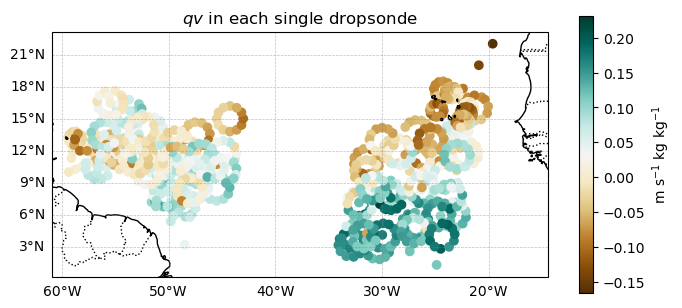

In [40]:
BCO_lon = -59.4288
BCO_lat = 13.1627

# - set control volume edges
vol_lon = [BCO_lon-0.5+360 , BCO_lon+15+360]  #[-60+360, -58+360]
vol_lat = [BCO_lat-5     , BCO_lat+5]  #[12.5, 14.5]


# - presenting area of interest

fig = plt.figure(figsize=(8, 6))
ax = plt.axes(projection=ccrs.PlateCarree())

# Add base features
ax.add_feature(cfeature.COASTLINE)
ax.add_feature(cfeature.BORDERS, linestyle=':')
ax.set_extent([vol_lon[0] - 1., vol_lon[1] + 30., vol_lat[0] - 8., vol_lat[1] + 5.], crs=ccrs.PlateCarree())


gl = ax.gridlines(draw_labels=True, 
                  linewidth=0.5, color='gray', alpha=0.5, linestyle='--')

# Turn on labels on bottom and left only
gl.top_labels = False
gl.right_labels = False

# Optionally format ticks (degrees + symbols)
gl.xformatter = cticker.LongitudeFormatter()
gl.yformatter = cticker.LatitudeFormatter()




## scatter the dropsondes lon and lat
sc = ax.scatter(beach3.launch_lon, beach3.launch_lat, c=qv.sel(altitude=slice(50, 500)).mean(dim="altitude"), cmap="BrBG", transform=ccrs.PlateCarree())
cbar = plt.colorbar(sc, ax=ax, shrink=0.6)
cbar.set_label(r"$\rm m~s^{-1}~kg~kg^{-1}$")
ax.set_title(r"$qv$ in each single dropsonde")


In [ ]:
counts = beach.sondes_per_circle.values
ends = np.cumsum(beach.sondes_per_circle.values)
starts = ends - beach.sondes_per_circle.values

sondes_to_clear = []

for i in beach.circle.values:
    if counts[i] < 6. :
        s = beach3.sel(sonde=slice(starts[i], ends[i])).sonde_id.values
        sondes_to_clear.append(s)
    

compute $\overline{q~v}$

In [31]:
counts = beach.sondes_per_circle.values  
ends = np.cumsum(counts)                 
starts = ends - counts                   

result = []

for i, _ in enumerate(beach.circle):
    circle_mean = qv.sel(sonde=slice(starts[i], ends[i])).mean(dim='sonde')
    result.append(circle_mean)

qv_bar = xr.concat(result, dim='circle')
qv_bar.name = 'qv_circle_mean'

qv_bar

<xarray.DataArray 'qv_circle_mean' (circle: 89, altitude: 1460)> Size: 520kB
array([[ 0.07167863,  0.06223146,  0.05139163, ...,         nan,
                nan,         nan],
       [ 0.09884086,  0.10418043,  0.10492771, ...,         nan,
                nan,         nan],
       [-0.00844709, -0.01193179, -0.01276469, ...,         nan,
                nan,         nan],
       ...,
       [ 0.05474182,  0.05837607,  0.05143856, ...,         nan,
                nan,         nan],
       [ 0.00700491,  0.01373421,  0.01116978, ...,         nan,
                nan,         nan],
       [ 0.04731697,  0.05071312,  0.05236277, ...,         nan,
                nan,         nan]], shape=(89, 1460), dtype=float32)
Coordinates:
  * altitude  (altitude) float64 12kB 0.0 10.0 20.0 ... 1.458e+04 1.459e+04
Dimensions without coordinates: circle
Attributes:
    method:   calculated from measured RH following Hardy 1998

/work/mh1498/m301248/conda/envs/env_hacka/lib/python3.12/site-packages/cartopy/mpl/geoaxes.py:1677: UserWarning: You passed both c and facecolor/facecolors for the markers. c has precedence over facecolor/facecolors. This behavior may change in the future.
  result = super().scatter(*args, **kwargs)


Text(0.5, 1.0, '$qv$ in each single dropsonde')

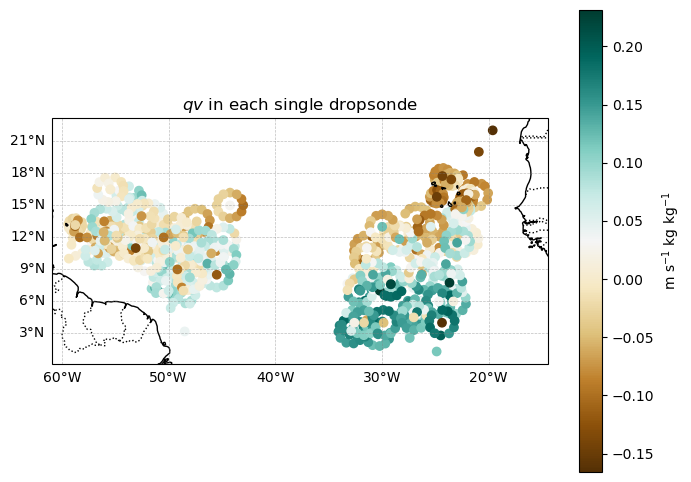

In [ ]:
# - presenting area of interest

fig = plt.figure(figsize=(8, 6))
ax = plt.axes(projection=ccrs.PlateCarree())

# Add base features
ax.add_feature(cfeature.COASTLINE)
ax.add_feature(cfeature.BORDERS, linestyle=':')
ax.set_extent([vol_lon[0] - 1., vol_lon[1] + 30., vol_lat[0] - 8., vol_lat[1] + 5.], crs=ccrs.PlateCarree())


gl = ax.gridlines(draw_labels=True, 
                  linewidth=0.5, color='gray', alpha=0.5, linestyle='--')

# Turn on labels on bottom and left only
gl.top_labels = False
gl.right_labels = False

# Optionally format ticks (degrees + symbols)
gl.xformatter = cticker.LongitudeFormatter()
gl.yformatter = cticker.LatitudeFormatter()




## scatter the dropsondes lon and lat
sc = ax.scatter(beach3.launch_lon, beach3.launch_lat,
                c=qv.sel(altitude=slice(50, 500)).mean(dim="altitude"),
                facecolors="none",
                cmap="BrBG", transform=ccrs.PlateCarree())

cbar = plt.colorbar(sc, ax=ax, shrink=0.6)
cbar.set_label(r"$\rm m~s^{-1}~kg~kg^{-1}$")

ax.scatter(beach.circle_lon, beach.circle_lat,
           c=qv_bar.sel(altitude=slice(50, 500)).mean(dim="altitude"),
           cmap="BrBG", transform=ccrs.PlateCarree())



ax.set_title(r"$qv$ in each single dropsonde")
